# **Google Drive Mount**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Dataset Path Set**

In [ ]:
import os
dataset_path = '/content/drive/MyDrive/ChiliDoc_Dataset'
print(os.listdir(dataset_path))

['Nutrition_Deficiency', 'Cercospora_Leaf_Spot', 'Bacterial_Spot', 'Healthy_Leaf', 'Curl_Virus', 'White_Spot']


# **Import Libraries**

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt

# **Data Preprocessing + Augmentation**

In [ ]:
img_size = 224
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # 80% train, 20% validation
)

train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 1287 images belonging to 6 classes.
Found 320 images belonging to 6 classes.


# **Create CNN Model**

In [ ]:
num_classes = train_data.num_classes  # class count automatically take (6)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_size, img_size, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

# **Model Train**

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 374s 9s/step - accuracy: 0.4110 - loss: 1.6649 - val_accuracy: 0.3094 - val_loss: 1.4056
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 38s 932ms/step - accuracy: 0.6154 - loss: 1.0268 - val_accuracy: 0.7625 - val_loss: 0.7357
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 34s 821ms/step - accuracy: 0.7514 - loss: 0.6680 - val_accuracy: 0.6812 - val_loss: 0.7195
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 38s 929ms/step - accuracy: 0.7949 - loss: 0.5578 - val_accuracy: 0.6969 - val_loss: 0.7430
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 34s 835ms/step - accuracy: 0.8516 - loss: 0.4408 - val_accuracy: 0.7344 - val_loss: 0.5647
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 35s 853ms/step - accuracy: 0.8462 - loss: 0.4526 - val_accuracy: 0.6719 - val_loss: 0.9133
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 34s 830ms/step - accuracy: 0.8539 - loss: 0.4166 - val_accuracy: 0.7937 - val_loss: 0.4864
Epoch 8/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 36s 873ms/step - accuracy: 0.8749 - loss: 0.3629 - val_accura

# **Validation Accuracy Check**

In [ ]:
val_loss, val_accuracy = model.evaluate(val_data)
print(f"CNN Validation Accuracy: {val_accuracy*100:.2f}%")

10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 982ms/step - accuracy: 0.7406 - loss: 0.8828
CNN Validation Accuracy: 74.06%


# **CNN Confusion Matrix**

10/10 ━━━━━━━━━━━━━━━━━━━━ 189s 21s/step
                      precision    recall  f1-score   support

      Bacterial_Spot       0.14      0.03      0.05        31
Cercospora_Leaf_Spot       0.00      0.00      0.00        36
          Curl_Virus       0.26      0.56      0.36        84
        Healthy_Leaf       0.23      0.05      0.09        91
Nutrition_Deficiency       0.06      0.03      0.04        39
          White_Spot       0.10      0.26      0.15        39

            accuracy                           0.20       320
           macro avg       0.13      0.15      0.11       320
        weighted avg       0.17      0.20      0.15       320



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


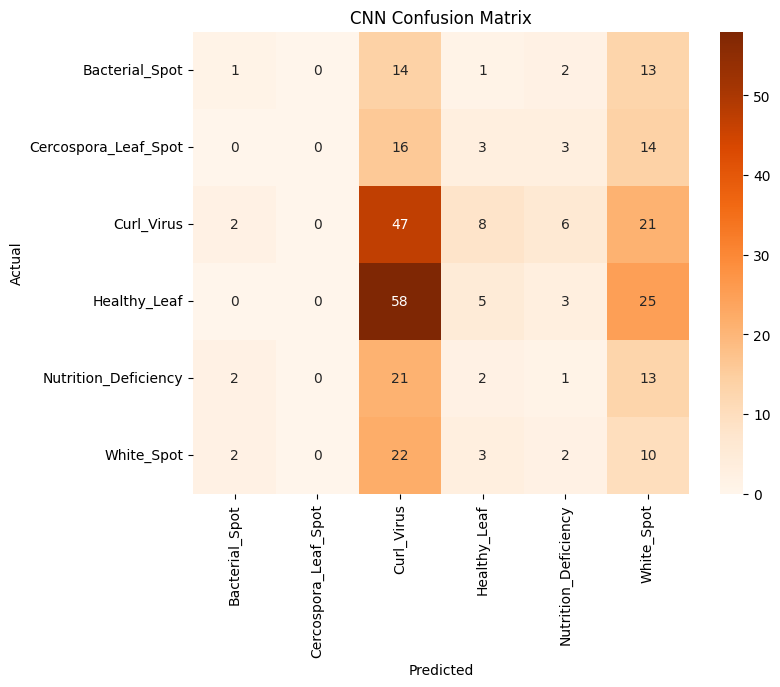

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

val_data.reset()
y_pred_probs = model.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_data.classes

class_labels = list(val_data.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_labels))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels, cmap='Oranges')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('CNN Confusion Matrix')
plt.show()

# **Accuracy/Loss Graph**

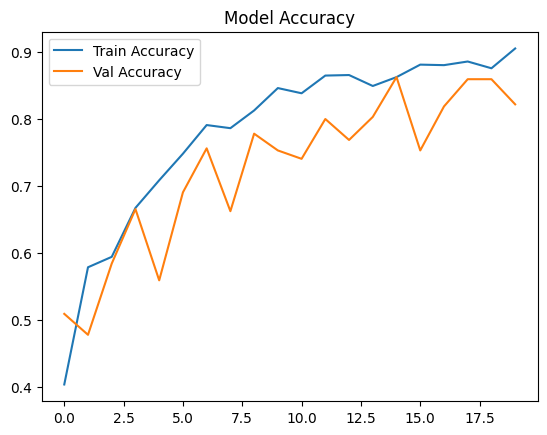

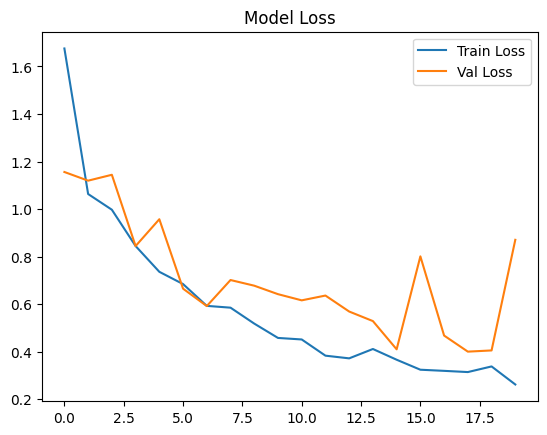

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

# **Model Save**

In [ ]:
model.save('/content/drive/MyDrive/ChiliDoc_Dataset/chilidoc_cnn_model.h5')
print("Model saved!")

Model saved!
